In [2]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# load the dataset
df = pd.read_csv("A1_Clinical_risk.csv")

# Check shape of the dataset
print("Rows, columns:", df.shape,"\n")

# Check row names, data types and null values
print(">>> Health df Info:")
print(df.info(),"\n")

# Check df basic stats (numerical columns)
print(">>> Health df stats:\n", df.describe(),"\n")

# Check df sample
print(">>> df Sample (head):\n", df.head(5))


Rows, columns: (500, 11) 

>>> Health df Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              500 non-null    int64  
 1   bp_index         500 non-null    float64
 2   chol_index       500 non-null    float64
 3   chol_index_2     500 non-null    float64
 4   lifestyle_score  500 non-null    float64
 5   stress_score     500 non-null    float64
 6   activity_index   500 non-null    float64
 7   random_marker_1  500 non-null    float64
 8   random_marker_2  500 non-null    float64
 9   visit_year       500 non-null    int64  
 10  risk_status      500 non-null    int64  
dtypes: float64(8), int64(3)
memory usage: 43.1 KB
None 

>>> Health df stats:
               age    bp_index  chol_index  chol_index_2  lifestyle_score  \
count  500.000000  500.000000  500.000000    500.000000       500.000000   
mean    54.864000 

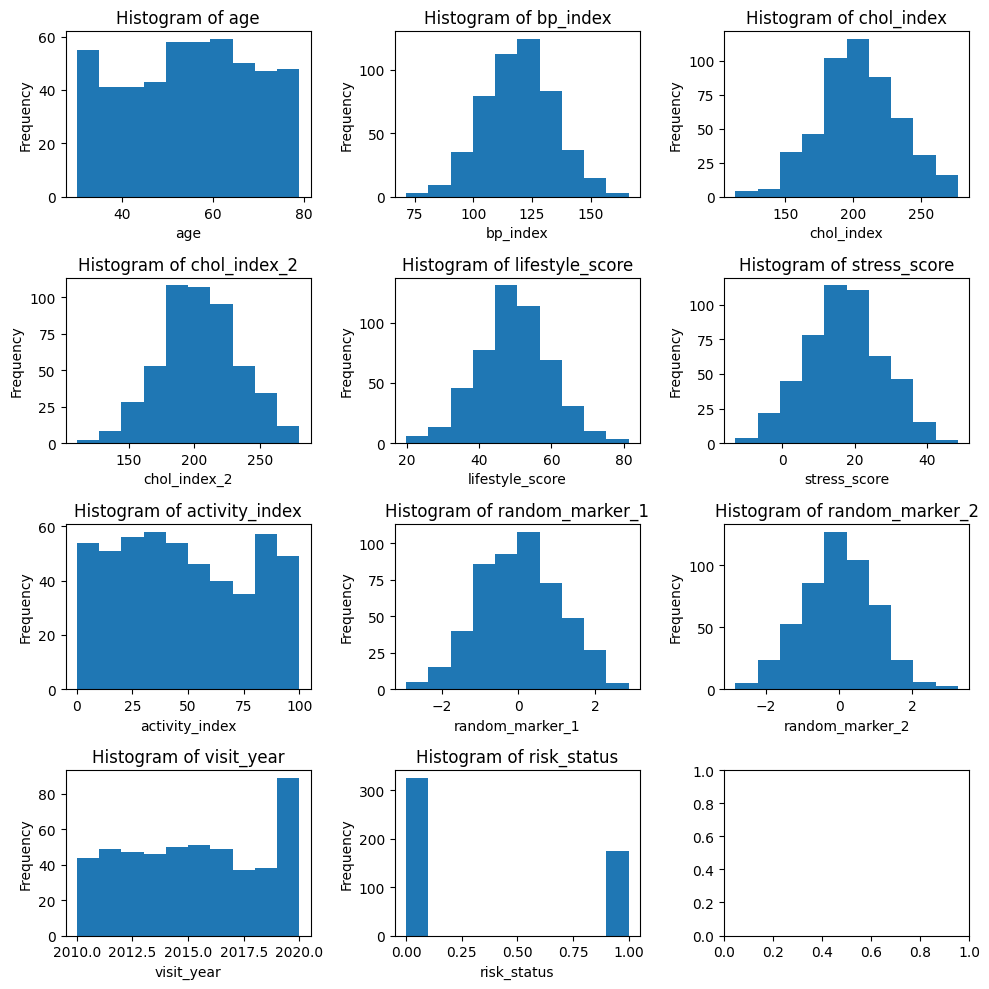

In [3]:
# Loop over each column
fig, axes = plt.subplots(4,3, figsize=(10, 10))

for i, col in enumerate(df.columns):

    # Plot histogram chart
    axes[i//3, i%3].hist(df[col])

    # Set plot titles and labels
    axes[i//3, i%3].set_title(f'Histogram of {col}')
    axes[i//3, i%3].set_xlabel(col)
    axes[i//3, i%3].set_ylabel('Frequency')
plt.tight_layout()
plt.show()


Histograms shows that most features have a relatively normal distribution, with the exception of age, activity_index and visit_year. Risk_status show a little more than 1/3 of people in risk.

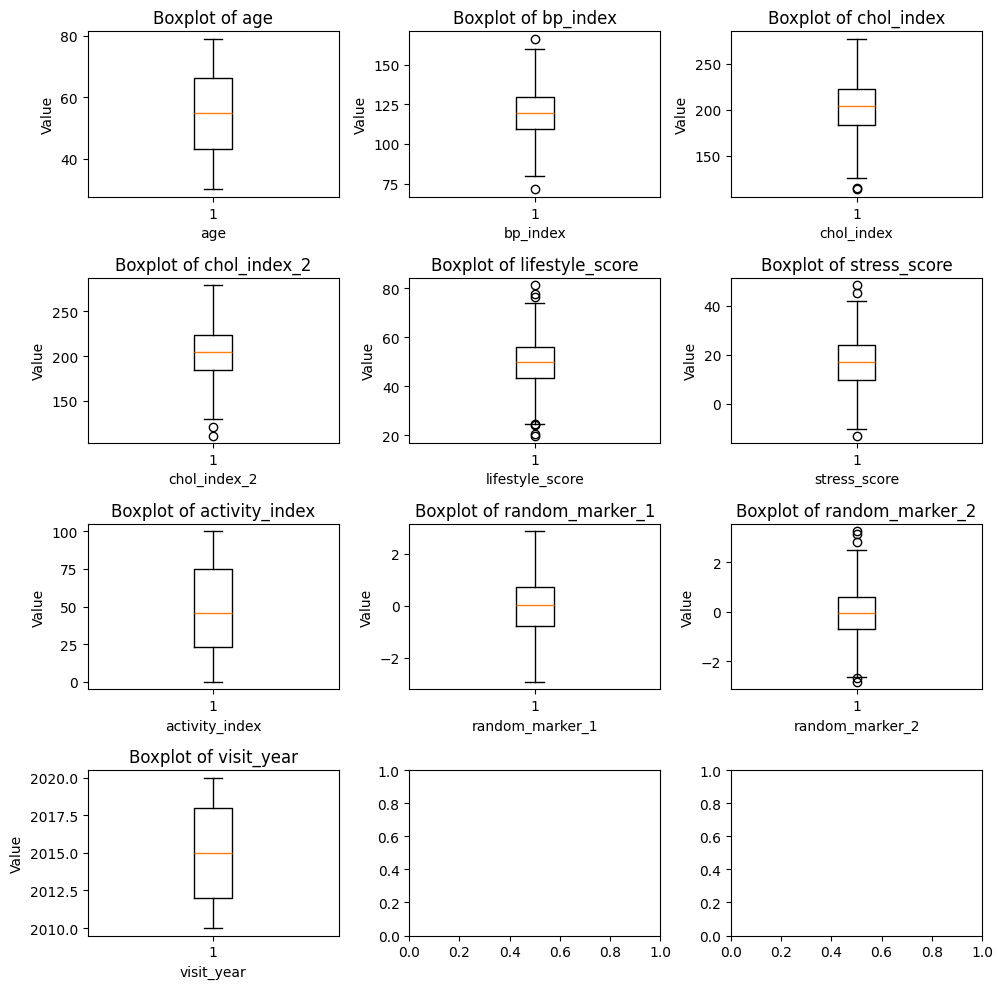

In [4]:
# Loop over each column
fig, axes = plt.subplots(4,3, figsize=(10, 10))

for i, col in enumerate(df.columns):
    if col != 'risk_status':
        # Plot boxplot chart
        axes[i//3, i%3].boxplot(df[col])

        # Set plot titles and labels
        axes[i//3, i%3].set_title(f'Boxplot of {col}')
        axes[i//3, i%3].set_xlabel(col)
        axes[i//3, i%3].set_ylabel('Value')
plt.tight_layout()
plt.show()


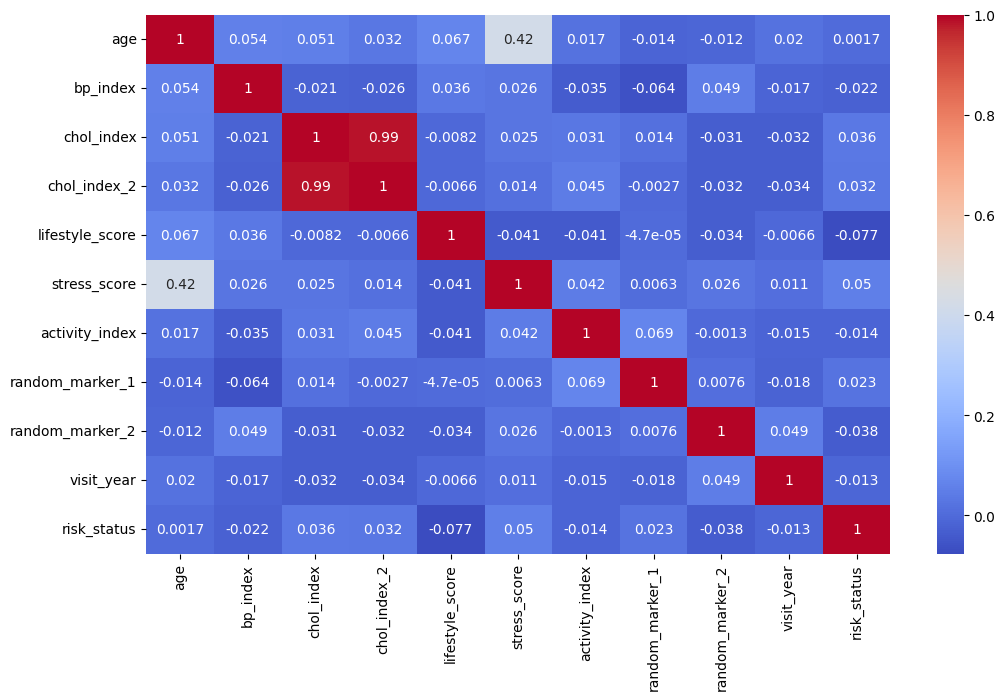

In [5]:
# Compute correlation matrix and plot heatmap
correlation_matrix = df.corr()
plt.figure(figsize=(12, 7))  
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

Boxplot confirms the interpretation from histograms and shows outliers on some of the features. Correlation matrix indicates that the majority of the features dont have a high correlation between them. Highest correlation is show between chol_index and chol_index2, which most likely are two measures in different situations or point in time, but since belong to the same individual, it makes sense to show that correlation. After that, the highest correlation is between age and stress_score, but at only 0.42, which indicates a weak to moderate relationship.

In [7]:
from scipy.stats import ttest_ind

# List of predictor columns
predictors = [
    'age',
    'bp_index',
    'chol_index',
    'chol_index_2',
    'lifestyle_score',
    'stress_score',
    'activity_index',
    'random_marker_1',
    'random_marker_2',
    'visit_year'
]

results = []

# Split groups
group0 = df[df['risk_status'] == 0]
group1 = df[df['risk_status'] == 1]

for col in predictors:
    stat, p_value = ttest_ind(
        group0[col],
        group1[col],
        equal_var=False  # This makes it Welch's t-test
    )
    
    results.append({
        'Variable': col,
        'Mean (Risk=0)': group0[col].mean(),
        'Mean (Risk=1)': group1[col].mean(),
        't-statistic': stat,
        'p-value': p_value
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='p-value')
print(results_df)


          Variable  Mean (Risk=0)  Mean (Risk=1)  t-statistic   p-value
4  lifestyle_score      50.221733      48.653340     1.765954  0.078190
5     stress_score      16.668641      17.795953    -1.126065  0.260893
8  random_marker_2      -0.011218      -0.090758     0.873119  0.383148
2       chol_index     202.978924     205.186620    -0.799901  0.424290
3     chol_index_2     203.505857     205.494949    -0.713449  0.476025
1         bp_index     119.796350     119.104791     0.510439  0.610033
7  random_marker_1       0.016310       0.065801    -0.482500  0.629787
6   activity_index      48.585594      47.743893     0.301445  0.763264
9       visit_year    2014.907692    2014.822857     0.294729  0.768362
0              age      54.846154      54.897143    -0.039025  0.968891


Welch’s t-test was used to examine the relationship between each continuous predictor and the binary outcome (risk_status). This test is appropriate because the objective is to compare the mean values of continuous variables between two independent groups (risk = 0 vs. risk = 1).

Welch’s t-test was chosen over the standard Student’s t-test because it does not assume equal variances between groups. Given the presence of some outliers and the potential for heterogeneity of variance across risk groups, Welch’s t-test provides a more robust and reliable comparison. Additionally, with a relatively large sample size (n = 500), the test is robust to mild deviations from normality due to the Central Limit Theorem.

Therefore, Welch’s t-test represents an appropriate and statistically robust method for comparing continuous predictors across the two independent risk groups. 

##### **Result**
Welch’s t-tests indicated no statistically significant differences in the mean values of any continuous predictors between individuals with and without risk_status (all p > 0.05). The smallest observed p-value was for lifestyle_score (p = 0.078), suggesting weak but non-significant evidence of a group difference.

In [21]:
# Features/target
X = df.drop(columns=["risk_status"])
y = df["risk_status"]

# Fixed split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Standardization for Logistic Regression
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

# Drop one cholesterol var (Option A)
X_train_A = X_train.drop(columns=["chol_index_2"])
X_test_A  = X_test.drop(columns=["chol_index_2"])

scaler_A = StandardScaler()
X_train_A_std = scaler_A.fit_transform(X_train_A)
X_test_A_std  = scaler_A.transform(X_test_A)

# Logistic Regression (one hyperparameter)
logreg = LogisticRegression(C=1.0, max_iter=200, random_state=42)
logreg.fit(X_train_A_std, y_train)
y_pred_lr = logreg.predict(X_test_A_std)

# Decision Tree (one hyperparameter)
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)
y_pred_dt = tree.predict(X_test)

# Metrics
def metrics(y_true, y_pred):
    return {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1":        f1_score(y_true, y_pred, zero_division=0),
    }

print("Logistic Regression:", metrics(y_test, y_pred_lr))
print("Decision Tree:", metrics(y_test, y_pred_dt))

Logistic Regression: {'Accuracy': 0.6466666666666666, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}
Decision Tree: {'Accuracy': 0.58, 'Precision': 0.38636363636363635, 'Recall': 0.32075471698113206, 'F1': 0.35051546391752575}


In [11]:
pca = PCA(n_components=None, random_state=42)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca  = pca.transform(X_test_std)

logreg_pca = LogisticRegression(C=1.0, max_iter=200, random_state=42)
logreg_pca.fit(X_train_pca, y_train)
y_pred_lr_pca = logreg_pca.predict(X_test_pca)

print("Logistic + PCA:", metrics(y_test, y_pred_lr_pca))
print("Explained variance:", pca.explained_variance_ratio_)

Logistic + PCA: {'Accuracy': 0.6466666666666666, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}
Explained variance: [0.19994022 0.14521587 0.1114266  0.10560836 0.10289076 0.09987377
 0.09045311 0.08800583 0.05530694 0.00127853]
